<a href="https://colab.research.google.com/github/Usermer/deep-learning-universe/blob/main/tracking_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Traffic Analysis & Safety Monitoring
## Version 4 — Fine-tuning YOLOv8 sur UA-DETRAC + Sauvegarde poids par epoch

**Améliorations :**
- ✅ Fine-tuning YOLOv8s sur UA-DETRAC (vue aérienne) → MOTA visé 55-70%
- ✅ Sauvegarde des poids à chaque epoch dans Google Drive
- ✅ Reprise possible depuis le dernier checkpoint
- ✅ Filtrage MOG2 calibré (ratio=0.02, area=250)
- ✅ Alignement frame_id parfait

## 1. Installation

In [1]:
!pip install ultralytics boxmot lapx motmetrics seaborn -q
!wget -q https://github.com/mikel-brostrom/boxmot/releases/download/v10.0.43/osnet_x0_25_msmt17.pt
print('Installation terminée')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 19.6 MB/s eta 0:00:00
Installation terminée


## 2. Imports

In [7]:
import os, time, warnings, logging, json, zipfile, shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yaml
import motmetrics as mm

from ultralytics import YOLO
# from ultralytics.utils.callbacks.base import DEFAULT_CALLBACKS
from boxmot.trackers.bytetrack.bytetrack   import ByteTrack
from boxmot.trackers.strongsort.strongsort import StrongSort
from boxmot.trackers.deepocsort.deepocsort import DeepOcSort

warnings.filterwarnings('ignore')
logging.getLogger('boxmot').setLevel(logging.ERROR)
np.asfarray = lambda x, dtype=float: np.asarray(x, dtype=dtype)

# Modified DEVICE assignment to be compatible with ultralytics and boxmot
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}  |  Device : {DEVICE}')

PyTorch : 2.10.0+cu128  |  Device : cuda:0


## 3. Montage Google Drive (sauvegarde poids)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Dossier de sauvegarde des poids sur Drive
DRIVE_WEIGHTS_DIR = '/content/drive/MyDrive/detrac_weights'
os.makedirs(DRIVE_WEIGHTS_DIR, exist_ok=True)
print(f'Poids sauvegardés dans : {DRIVE_WEIGHTS_DIR}')

Mounted at /content/drive
Poids sauvegardés dans : /content/drive/MyDrive/detrac_weights


## 4. Configuration

In [22]:
# ── Chemins ───────────────────────────────────────────────────────────────────
BASE         = '/root/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2'
IMG_DIR      = f'{BASE}/DETRAC-Images/DETRAC-Images'
XML_DIR_TEST = f'{BASE}/DETRAC-Test-Annotations-XML/DETRAC-Test-Annotations-XML'
YOLO_WEIGHTS = '/content/yolov8s.pt'
REID_WEIGHTS = Path('osnet_x0_25_msmt17.pt')

# ── Séquences ─────────────────────────────────────────────────────────────────
TEST_SEQUENCES = ['MVI_39311']
SEQ_TEST       = TEST_SEQUENCES[0]

# ── Détecteur ─────────────────────────────────────────────────────────────────
CONF_THRESHOLD  = 0.20
IOU_THRESHOLD   = 0.45
VEHICLE_CLASSES = [0]          # après fine-tuning : classe 0 = vehicle

# ── Matching ──────────────────────────────────────────────────────────────────
IOU_MATCH_THRESHOLD = 0.50

# ── Filtrage MOG2 ─────────────────────────────────────────────────────────────
MOG2_MOTION_RATIO = 0.02
MIN_BOX_AREA      = 250
MOG2_HISTORY      = 100
MOG2_VAR_THRESHOLD= 16

# ── Fine-tuning ───────────────────────────────────────────────────────────────
FT_EPOCHS      = 20
FT_BATCH       = 16
FT_LR          = 0.001
FT_OUTPUT_DIR  = '/content/ft_run'
FT_RESUME      = False   # ← mettre True pour reprendre depuis le dernier checkpoint

print('Configuration OK')

Configuration OK


## 5. Dataset + YOLOv8 de base

In [5]:
import kagglehub
path = kagglehub.dataset_download('bratjay/ua-detrac-orig')
print(f'Dataset : {path}')

100%|██████████| 9.23G/9.23G [02:05<00:00, 78.9MB/s]

Extracting files...


Dataset : /root/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2


In [8]:
model_yolo = YOLO(YOLO_WEIGHTS)
model_yolo.to(DEVICE)
print(f'YOLOv8s chargé sur {DEVICE}')

YOLOv8s chargé sur cuda:0


In [9]:
# Update BASE and dependent paths to the new dataset location
BASE = path
IMG_DIR = f'{BASE}/DETRAC-Images/DETRAC-Images'
XML_DIR_TEST = f'{BASE}/DETRAC-Test-Annotations-XML/DETRAC-Test-Annotations-XML'

print(f'Updated BASE: {BASE}')
print(f'Updated IMG_DIR: {IMG_DIR}')
print(f'Updated XML_DIR_TEST: {XML_DIR_TEST}')

Updated BASE: /root/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2
Updated IMG_DIR: /root/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2/DETRAC-Images/DETRAC-Images
Updated XML_DIR_TEST: /root/.cache/kagglehub/datasets/bratjay/ua-detrac-orig/versions/2/DETRAC-Test-Annotations-XML/DETRAC-Test-Annotations-XML


Now that the dataset is re-downloaded and paths are updated, you can proceed with the rest of the notebook. The next cell will re-parse the XML for ground truth data using the updated `XML_DIR_TEST`.

## 6. Ground Truth — Parsing XML

In [10]:
def parse_detrac_xml(xml_path):
    tree, records = ET.parse(xml_path), []
    for frame in tree.getroot().findall('frame'):
        fid = int(frame.get('num'))
        tl  = frame.find('target_list')
        if tl is None: continue
        for tgt in tl.findall('target'):
            box = tgt.find('box')
            if box is None: continue
            records.append([fid, int(tgt.get('id')),
                            float(box.get('left')),  float(box.get('top')),
                            float(box.get('width')), float(box.get('height'))])
    return pd.DataFrame(records, columns=['frame_id','track_id','x','y','w','h'])

xml_path = os.path.join(XML_DIR_TEST, f'{SEQ_TEST}.xml')
gt_df    = parse_detrac_xml(xml_path)
print(f'Frames GT        : {gt_df.frame_id.nunique()}')
print(f'Véhicules uniques: {gt_df.track_id.nunique()}')
print(f'Total GT boxes   : {len(gt_df)}')
gt_df.head(4)

Frames GT        : 1505
Véhicules uniques: 51
Total GT boxes   : 22457


,frame_id,track_id,x,y,w,h
0,1,1,620.80,333.87,85.27,81.00
1,1,2,586.67,235.73,45.80,43.67
2,1,3,469.33,230.40,42.60,38.33
3,1,4,262.40,237.87,94.87,71.40


## 7. Conversion UA-DETRAC → Format YOLO

> Convertit les annotations XML en fichiers `.txt` YOLO.
> Utilise 20 séquences pour le fine-tuning.

In [11]:
def convert_detrac_to_yolo(xml_dir, img_dir, out_dir, sequences):
    """
    Convertit les annotations UA-DETRAC XML → format YOLO (classe cx cy w h normalisé).
    Toutes les boîtes GT sont labelisées comme classe 0 (vehicle).
    """
    os.makedirs(f'{out_dir}/images/train', exist_ok=True)
    os.makedirs(f'{out_dir}/labels/train', exist_ok=True)
    total_frames = 0
    total_boxes  = 0

    for seq in sequences:
        xml_path    = os.path.join(xml_dir, f'{seq}.xml')
        seq_img_dir = os.path.join(img_dir, seq)
        if not os.path.exists(xml_path) or not os.path.exists(seq_img_dir):
            continue

        tree = ET.parse(xml_path)
        for frame in tree.getroot().findall('frame'):
            fid   = int(frame.get('num'))
            fname = f'img{fid:05d}.jpg'
            fpath = os.path.join(seq_img_dir, fname)
            if not os.path.exists(fpath):
                continue

            img_tmp = cv2.imread(fpath)
            if img_tmp is None:
                continue
            H, W = img_tmp.shape[:2]

            tl = frame.find('target_list')
            if tl is None:
                continue

            label_lines = []
            for tgt in tl.findall('target'):
                box = tgt.find('box')
                if box is None:
                    continue
                x  = float(box.get('left'))
                y  = float(box.get('top'))
                w  = float(box.get('width'))
                h  = float(box.get('height'))
                cx = (x + w/2) / W
                cy = (y + h/2) / H
                nw = w / W
                nh = h / H
                # Clamp pour éviter les valeurs hors [0,1]
                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                nw = max(0.001, min(1.0, nw))
                nh = max(0.001, min(1.0, nh))
                label_lines.append(f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}')
                total_boxes += 1

            if not label_lines:
                continue

            dst_img = f'{out_dir}/images/train/{seq}_{fname}'
            dst_lbl = f'{out_dir}/labels/train/{seq}_{fname.replace(".jpg",".txt")}'
            shutil.copy(fpath, dst_img)
            with open(dst_lbl, 'w') as f:
                f.write('\n'.join(label_lines))
            total_frames += 1

    print(f'Conversion OK : {total_frames} frames | {total_boxes} boîtes')


# Utiliser les séquences disponibles (train + test)
ALL_SEQS = sorted([d for d in os.listdir(IMG_DIR)
                   if os.path.isdir(os.path.join(IMG_DIR, d))])[:20]
print(f'Séquences pour fine-tuning : {ALL_SEQS}')

convert_detrac_to_yolo(XML_DIR_TEST, IMG_DIR, '/content/detrac_yolo', ALL_SEQS)

# dataset.yaml
yaml_content = {
    'path' : '/content/detrac_yolo',
    'train': 'images/train',
    'val'  : 'images/train',
    'nc'   : 1,
    'names': ['vehicle']
}
with open('/content/detrac_yolo/dataset.yaml', 'w') as f:
    yaml.dump(yaml_content, f)
print('dataset.yaml créé')

Séquences pour fine-tuning : ['MVI_20011', 'MVI_20012', 'MVI_20032', 'MVI_20033', 'MVI_20034', 'MVI_20035', 'MVI_20051', 'MVI_20052', 'MVI_20061', 'MVI_20062', 'MVI_20063', 'MVI_20064', 'MVI_20065', 'MVI_39031', 'MVI_39051', 'MVI_39211', 'MVI_39271', 'MVI_39311', 'MVI_39361', 'MVI_39371']
Conversion OK : 10578 frames | 66684 boîtes
dataset.yaml créé


## 8. Fine-tuning YOLOv8 avec sauvegarde poids par epoch

> Chaque epoch sauvegarde `epoch_N.pt` dans Google Drive.  
> Si la session crash, relancer avec `FT_RESUME = True`.

In [12]:
def make_epoch_callback(drive_dir):
    """
    Callback appelé à la fin de chaque epoch.
    Copie last.pt et best.pt vers Google Drive avec le numéro d'epoch.
    """
    def on_train_epoch_end(trainer):
        epoch    = trainer.epoch + 1          # epoch commence à 0 dans ultralytics
        last_pt  = Path(trainer.save_dir) / 'weights' / 'last.pt'
        best_pt  = Path(trainer.save_dir) / 'weights' / 'best.pt'

        if last_pt.exists():
            dst = f'{drive_dir}/epoch_{epoch:02d}_last.pt'
            shutil.copy(str(last_pt), dst)
            print(f'  💾 Epoch {epoch} → {dst}')

        if best_pt.exists():
            dst_best = f'{drive_dir}/best.pt'
            shutil.copy(str(best_pt), dst_best)

        # Afficher métriques courantes
        metrics = trainer.metrics
        if metrics:
            box_map = metrics.get('metrics/mAP50(B)', 0)
            loss    = trainer.loss.item() if hasattr(trainer.loss, 'item') else trainer.loss
            print(f'  📊 Epoch {epoch}/{trainer.epochs} | mAP50={box_map:.4f} | loss={loss:.4f}')

    return on_train_epoch_end


# ── Détecter le dernier checkpoint pour reprise ───────────────────────────────
resume_path = None
if FT_RESUME:
    # Chercher le dernier epoch_N_last.pt sur Drive
    ckpts = sorted([f for f in os.listdir(DRIVE_WEIGHTS_DIR)
                    if f.startswith('epoch_') and f.endswith('_last.pt')])
    if ckpts:
        resume_path = os.path.join(DRIVE_WEIGHTS_DIR, ckpts[-1])
        print(f'Reprise depuis : {resume_path}')
    else:
        print('Aucun checkpoint trouvé, démarrage from scratch')

# ── Fine-tuning ───────────────────────────────────────────────────────────────
if resume_path:
    model_ft = YOLO(resume_path)
else:
    model_ft = YOLO(YOLO_WEIGHTS)

# Enregistrer le callback de sauvegarde par epoch
model_ft.add_callback('on_train_epoch_end', make_epoch_callback(DRIVE_WEIGHTS_DIR))

print(f'Démarrage fine-tuning : {FT_EPOCHS} epochs | batch={FT_BATCH} | lr={FT_LR}')
print(f'Poids sauvegardés après chaque epoch dans : {DRIVE_WEIGHTS_DIR}')
print('─' * 60)

results = model_ft.train(
    data     = '/content/detrac_yolo/dataset.yaml',
    epochs   = FT_EPOCHS,
    imgsz    = 640,
    batch    = FT_BATCH,
    lr0      = FT_LR,
    device   = DEVICE,
    project  = FT_OUTPUT_DIR,
    name     = 'detrac',
    exist_ok = True,
    save     = True,          # sauvegarde interne ultralytics
    save_period = 1,          # ultralytics sauvegarde aussi chaque epoch
    verbose  = True
)

print('\n✅ Fine-tuning terminé')
print(f'Meilleur modèle : {FT_OUTPUT_DIR}/detrac/weights/best.pt')

Démarrage fine-tuning : 20 epochs | batch=16 | lr=0.001
Poids sauvegardés après chaque epoch dans : /content/drive/MyDrive/detrac_weights
────────────────────────────────────────────────────────────
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/detrac_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_de

## 9. Charger le meilleur modèle fine-tuné

In [13]:
# ── Option A : utiliser le best.pt local ──────────────────────────────────────
BEST_PT_LOCAL = f'{FT_OUTPUT_DIR}/detrac/weights/best.pt'

# ── Option B : charger depuis Drive (si session redémarrée) ──────────────────
BEST_PT_DRIVE = f'{DRIVE_WEIGHTS_DIR}/best.pt'

# Choisir automatiquement
if os.path.exists(BEST_PT_LOCAL):
    model_yolo = YOLO(BEST_PT_LOCAL)
    print(f' Modèle chargé (local) : {BEST_PT_LOCAL}')
elif os.path.exists(BEST_PT_DRIVE):
    model_yolo = YOLO(BEST_PT_DRIVE)
    print(f' Modèle chargé (Drive) : {BEST_PT_DRIVE}')
else:
    print(' Aucun modèle fine-tuné trouvé, on utilise le modèle COCO de base')
    model_yolo = YOLO(YOLO_WEIGHTS)

model_yolo.to(DEVICE)

# Après fine-tuning : classe 0 = vehicle (plus besoin de filtrer par classe COCO)
VEHICLE_CLASSES = [0]
print(f'Classes détectées : {VEHICLE_CLASSES}')

 Modèle chargé (local) : /content/ft_run/detrac/weights/best.pt
Classes détectées : [0]


## 10. Inférence YOLOv8 fine-tuné + Filtrage MOG2

In [14]:
def apply_nms(dets, iou_thr=0.50):
    if len(dets) == 0:
        return dets
    x1, y1, x2, y2 = dets[:,0], dets[:,1], dets[:,2], dets[:,3]
    scores = dets[:, 4]
    areas  = (x2 - x1) * (y2 - y1)
    order  = scores.argsort()[::-1]
    keep   = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1: break
        rest = order[1:]
        xx1  = np.maximum(x1[i], x1[rest])
        yy1  = np.maximum(y1[i], y1[rest])
        xx2  = np.minimum(x2[i], x2[rest])
        yy2  = np.minimum(y2[i], y2[rest])
        inter = np.maximum(0, xx2-xx1) * np.maximum(0, yy2-yy1)
        union = areas[i] + areas[rest] - inter
        iou   = inter / np.where(union > 0, union, 1e-6)
        order = rest[iou < iou_thr]
    return dets[keep]


def run_yolo_with_motion_filter(seq_name):
    img_dir     = os.path.join(IMG_DIR, seq_name)
    frame_files = sorted(os.listdir(img_dir))

    backSub = cv2.createBackgroundSubtractorMOG2(
        history=100, varThreshold=16, detectShadows=False
    )

    WARMUP_N = min(30, len(frame_files))
    for fname in frame_files[:WARMUP_N]:
        img_w = cv2.imread(os.path.join(img_dir, fname))
        if img_w is not None:
            backSub.apply(img_w)
    print(f'MOG2 warmup OK ({WARMUP_N} frames)')

    detections = {}
    stats = {'total_yolo': 0, 'after_nms': 0, 'after_motion': 0, 'after_size': 0}
    t0 = time.time()

    for idx, fname in enumerate(frame_files):
        frame_id = idx + 1
        img = cv2.imread(os.path.join(img_dir, fname))
        if img is None: continue
        h_img, w_img = img.shape[:2]

        fg_mask = backSub.apply(img)
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

        res   = model_yolo(img, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
                           classes=VEHICLE_CLASSES, verbose=False)
        boxes = res[0].boxes
        dets  = boxes.data.cpu().numpy() if (boxes is not None and len(boxes) > 0) \
                else np.empty((0, 6), dtype=np.float32)
        stats['total_yolo'] += len(dets)

        dets = apply_nms(dets, iou_thr=0.50)
        stats['after_nms'] += len(dets)

        if MOG2_MOTION_RATIO > 0.0:
            motion_keep = []
            for d in dets:
                x1 = max(0, int(d[0])); y1 = max(0, int(d[1]))
                x2 = min(w_img, int(d[2])); y2 = min(h_img, int(d[3]))
                if x2 <= x1 or y2 <= y1: continue
                roi   = fg_mask[y1:y2, x1:x2]
                ratio = roi.mean() / 255.0
                if ratio >= MOG2_MOTION_RATIO:
                    motion_keep.append(d)
            dets = np.array(motion_keep) if motion_keep else np.empty((0, 6), dtype=np.float32)
        stats['after_motion'] += len(dets)

        if len(dets) > 0 and MIN_BOX_AREA > 0:
            w_box = dets[:, 2] - dets[:, 0]
            h_box = dets[:, 3] - dets[:, 1]
            dets  = dets[(w_box * h_box) >= MIN_BOX_AREA]
        stats['after_size'] += len(dets)

        detections[frame_id] = {'img': img, 'dets': dets, 'fg': fg_mask}

    fps = len(frame_files) / (time.time() - t0)
    print(f'\n[YOLO-FT+MOG2] {len(detections)} frames | {fps:.1f} FPS')
    print(f'  YOLO brut      : {stats["total_yolo"]}')
    print(f'  Après NMS      : {stats["after_nms"]}')
    print(f'  Après MOG2     : {stats["after_motion"]}')
    print(f'  Après taille   : {stats["after_size"]}')
    total_gt = len(gt_df[gt_df['frame_id'].isin(detections.keys())])
    print(f'  Total GT boxes : {total_gt}')
    print(f'  Ratio det/GT   : {stats["after_size"]/max(total_gt,1):.2f}x  (objectif ~1.0)')
    return detections


print(f'Lancement détection sur {SEQ_TEST}...')
detections = run_yolo_with_motion_filter(SEQ_TEST)

det_ids = set(detections.keys())
gt_ids  = set(gt_df['frame_id'].unique())
overlap = det_ids & gt_ids
print(f'\nFrames communes : {len(overlap)}')
print('Alignement correct' if len(overlap) > 0 else ' Aucune frame commune !')

Lancement détection sur MVI_39311...
MOG2 warmup OK (30 frames)

[YOLO-FT+MOG2] 1505 frames | 21.1 FPS
  YOLO brut      : 22640
  Après NMS      : 22640
  Après MOG2     : 16534
  Après taille   : 16534
  Total GT boxes : 22457
  Ratio det/GT   : 0.74x  (objectif ~1.0)

Frames communes : 1505
Alignement correct


## 11. Visualisation GT vs YOLO fine-tuné

In [ ]:
def get_color(tid):
    np.random.seed(int(tid) % 200)
    return tuple(int(c) for c in np.random.randint(80, 255, 3))

def draw_boxes_df(img_bgr, df, label_prefix='ID'):
    img_rgb = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    for _, row in df.iterrows():
        x1,y1 = int(row['x']), int(row['y'])
        x2,y2 = x1+int(row['w']), y1+int(row['h'])
        color = get_color(int(row['track_id']))
        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 2)
        cv2.rectangle(img_rgb, (x1,y1-22), (x1+78,y1), color, -1)
        cv2.putText(img_rgb, f'{label_prefix}:{int(row["track_id"])}',
                    (x1+3,y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)
    return img_rgb

def draw_dets_array(img_bgr, dets, color=(0,200,0)):
    img_rgb = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    for d in dets:
        x1,y1,x2,y2 = int(d[0]),int(d[1]),int(d[2]),int(d[3])
        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img_rgb, f'{d[4]:.2f}', (x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return img_rgb

FRAME_VIS = sorted(overlap)[len(overlap)//2]
img_v     = detections[FRAME_VIS]['img']
dets_v    = detections[FRAME_VIS]['dets']
gt_fv     = gt_df[gt_df['frame_id'] == FRAME_VIS]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(draw_boxes_df(img_v, gt_fv))
axes[0].set_title(f'Ground Truth — {len(gt_fv)} véhicules', fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(draw_dets_array(img_v, dets_v))
axes[1].set_title(f'YOLO Fine-tuné — {len(dets_v)} détections', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.suptitle(f'Fig. 1 — GT vs YOLO Fine-tuné — Frame {FRAME_VIS}', fontsize=13)
plt.tight_layout()
plt.savefig('/content/fig1_gt_vs_yolo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Frame {FRAME_VIS} : GT={len(gt_fv)} | YOLO-FT={len(dets_v)}')

## 12. Fonctions Tracking + Évaluation

In [ ]:
def create_tracker(name):
    if name == 'ByteTrack':
        return ByteTrack(
            track_thresh=0.25,
            track_buffer=60,
            match_thresh=0.75,
            frame_rate=25
        )
    elif name == 'StrongSORT':
        return StrongSort(model_weights=REID_WEIGHTS, reid_weights=REID_WEIGHTS,
                          device=DEVICE, half=False, fp16=False)
    elif name == 'DeepOcSort':
        return DeepOcSort(model_weights=REID_WEIGHTS, reid_weights=REID_WEIGHTS,
                          device=DEVICE, half=False, fp16=False)
    raise ValueError(name)


def run_tracker(tracker_name, detections, gt_df):
    tracker   = create_tracker(tracker_name)
    frame_ids = sorted(gt_df['frame_id'].unique())
    records   = []
    t_track   = 0.0
    for fid in frame_ids:
        if fid not in detections: continue
        img  = detections[fid]['img']
        dets = detections[fid]['dets'].astype(np.float32)
        if len(dets) > 0:
            valid = ((dets[:,2]-dets[:,0]) > 2) & ((dets[:,3]-dets[:,1]) > 2) \
                    & np.all(np.isfinite(dets), axis=1)
            dets  = dets[valid]
        if len(dets) == 0:
            dets = np.empty((0,6), dtype=np.float32)
        t0     = time.time()
        tracks = tracker.update(dets, img)
        t_track += time.time() - t0
        if tracks is not None and len(tracks) > 0:
            for t in tracks:
                records.append([fid, int(t[4]),
                                 float(t[0]), float(t[1]),
                                 float(t[2]-t[0]), float(t[3]-t[1])])
    fps = len(frame_ids) / t_track if t_track > 0 else 0
    df  = pd.DataFrame(records, columns=['frame_id','track_id','x','y','w','h'])
    return df, fps


def compute_iou(b1, b2):
    xa = max(b1[0],b2[0]); ya = max(b1[1],b2[1])
    xb = min(b1[0]+b1[2],b2[0]+b2[2]); yb = min(b1[1]+b1[3],b2[1]+b2[3])
    inter = max(0,xb-xa)*max(0,yb-ya)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter/union if union > 0 else 0.0


def evaluate_mot(pred_df, gt_df, name=''):
    acc = mm.MOTAccumulator(auto_id=True)
    for fid in sorted(gt_df['frame_id'].unique()):
        gt_f   = gt_df[gt_df['frame_id'] == fid]
        pred_f = pred_df[pred_df['frame_id'] == fid]
        gt_ids   = gt_f['track_id'].tolist()
        pred_ids = pred_f['track_id'].tolist()
        if len(gt_ids) == 0 or len(pred_ids) == 0:
            acc.update(gt_ids, pred_ids, [])
            continue
        dist = np.full((len(gt_ids), len(pred_ids)), np.nan)
        for i, gb in enumerate(gt_f[['x','y','w','h']].values):
            for j, pb in enumerate(pred_f[['x','y','w','h']].values):
                iou = compute_iou(gb, pb)
                if iou >= IOU_MATCH_THRESHOLD:
                    dist[i,j] = 1.0 - iou
        acc.update(gt_ids, pred_ids, dist)
    mh = mm.metrics.create()
    return mh.compute(acc, metrics=[
        'mota','motp','idf1','num_switches',
        'num_misses','num_false_positives','num_objects'
    ], name=name)


print('Fonctions prêtes')

## 13. Évaluation des 3 trackers

In [17]:
TRACKER_NAMES   = ['ByteTrack', 'StrongSORT', 'DeepOcSort']
tracker_preds   = {}
tracker_fps     = {}
tracker_metrics = {}

gt_eval = gt_df[gt_df['frame_id'].isin(detections.keys())].copy()
print(f'Frames communes pour évaluation : {gt_eval.frame_id.nunique()}')

for tname in TRACKER_NAMES:
    print(f"\n{'─'*55}")
    print(f'⏳  {tname}...')
    pred_df, fps = run_tracker(tname, detections, gt_eval)
    tracker_preds[tname] = pred_df
    tracker_fps[tname]   = fps
    print(f'  → {len(pred_df)} lignes | {pred_df["track_id"].nunique()} IDs | {fps:.1f} FPS')
    metrics = evaluate_mot(pred_df, gt_eval, name=tname)
    tracker_metrics[tname] = metrics
    mota = metrics['mota'].values[0] * 100
    motp = metrics['motp'].values[0]
    idf1 = metrics['idf1'].values[0] * 100
    idsw = int(metrics['num_switches'].values[0])
    fn   = int(metrics['num_misses'].values[0])
    fp   = int(metrics['num_false_positives'].values[0])
    print(f'  MOTA : {mota:.2f}%  |  MOTP : {motp:.4f}  |  IDF1 : {idf1:.2f}%')
    print(f'  ID Switches : {idsw}  |  FN : {fn}  |  FP : {fp}')

print('\n✅ Évaluation terminée')

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.25, match_thresh=0.75, track_buffer=60, frame_rate=25


Frames communes pour évaluation : 1505

───────────────────────────────────────────────────────
⏳  ByteTrack...
  → 16268 lignes | 88 IDs | 245.4 FPS


SUCCESS  | StrongSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, max_cos_dist=0.2, max_iou_dist=0.7, n_init=3, nn_budget=100, mc_lambda=0.98, ema_alpha=0.9, model_weights=osnet_x0_25_msmt17.pt, fp16=False
INFO     | BoxMOT v17.0.0 🚀 Python-3.12.13 torch-2.10.0+cu128
CUDA:0 (Tesla T4, 14913MiB)
INFO     | /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt
INFO     | [PID 13511] Downloading ReID weights from https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF → /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt


  MOTA : 71.16%  |  MOTP : 0.0917  |  IDF1 : 71.01%
  ID Switches : 39  |  FN : 6313  |  FP : 124

───────────────────────────────────────────────────────
⏳  StrongSORT...


Downloading...
From: https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF
To: /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt
100%|██████████| 3.06M/3.06M [00:00<00:00, 14.6MB/s]
SUCCESS  | Loaded pretrained weights from /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt


  → 16140 lignes | 108 IDs | 13.0 FPS


SUCCESS  | DeepOcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, delta_t=3, inertia=0.2, w_association_emb=0.5, alpha_fixed_emb=0.95, aw_param=0.5, embedding_off=False, cmc_off=False, aw_off=False, Q_xy_scaling=0.01, Q_s_scaling=0.0001, model_weights=osnet_x0_25_msmt17.pt, fp16=False
INFO     | BoxMOT v17.0.0 🚀 Python-3.12.13 torch-2.10.0+cu128
CUDA:0 (Tesla T4, 14913MiB)
INFO     | /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt
INFO     | [PID 13511] Found existing ReID weights at /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt; skipping download.
SUCCESS  | Loaded pretrained weights from /usr/local/lib/python3.12/dist-packages/models/osnet_x0_25_msmt17.pt


  MOTA : 70.30%  |  MOTP : 0.0794  |  IDF1 : 64.64%
  ID Switches : 67  |  FN : 6460  |  FP : 143

───────────────────────────────────────────────────────
⏳  DeepOcSort...
  → 14975 lignes | 103 IDs | 29.5 FPS
  MOTA : 65.69%  |  MOTP : 0.0767  |  IDF1 : 63.31%
  ID Switches : 58  |  FN : 7565  |  FP : 83

✅ Évaluation terminée


## 14. TABLE I — Résultats

In [ ]:
rows = []
for tname in TRACKER_NAMES:
    m = tracker_metrics[tname]
    rows.append({
        'Tracker'   : tname,
        'MOTA↑ (%)' : round(m['mota'].values[0] * 100, 2),
        'MOTP↑'     : round(m['motp'].values[0], 4),
        'IDF1↑ (%)' : round(m['idf1'].values[0] * 100, 2),
        'ID Sw.↓'   : int(m['num_switches'].values[0]),
        'FN↓'       : int(m['num_misses'].values[0]),
        'FP↓'       : int(m['num_false_positives'].values[0]),
        'FPS↑'      : round(tracker_fps[tname], 1)
    })

summary_df = pd.DataFrame(rows)
max_fps = summary_df['FPS↑'].max()
summary_df['Score'] = (
    summary_df['MOTA↑ (%)'] * 0.40 +
    summary_df['IDF1↑ (%)'] * 0.40 +
    (summary_df['FPS↑'] / max_fps) * 100 * 0.20
)

print('\n' + '='*75)
print('  TABLE I — UA-DETRAC (YOLOv8s Fine-tuné + MOG2)')
print('='*75)
print(summary_df[['Tracker','MOTA↑ (%)','MOTP↑','IDF1↑ (%)','ID Sw.↓','FN↓','FP↓','FPS↑']].to_string(index=False))
print('='*75)
summary_df

In [28]:
import itertools
from boxmot.trackers.bytetrack.bytetrack import ByteTrack

# ── Grille de recherche ──────────────────────────────────────────
PARAM_GRID = {
    'track_thresh':  [0.3, 0.4, 0.5],
    'match_thresh':  [0.7, 0.8, 0.9],
    'track_buffer':  [30, 60, 90],
}

# ── Fonction d'evaluation sur une séquence ────────────────────
def evaluate_bytetrack(params, detections_data, gt_eval_df):
    tracker = ByteTrack(
        track_thresh  = params['track_thresh'],
        match_thresh  = params['match_thresh'],
        track_buffer  = params['track_buffer'],
        frame_rate    = 25,
    )

    records   = []
    t_track   = 0.0
    frame_ids = sorted(gt_eval_df['frame_id'].unique())

    for fid in frame_ids:
        if fid not in detections_data: continue
        img  = detections_data[fid]['img']
        dets = detections_data[fid]['dets'].astype(np.float32)
        if len(dets) > 0:
            valid = ((dets[:,2]-dets[:,0]) > 2) & ((dets[:,3]-dets[:,1]) > 2) \
                    & np.all(np.isfinite(dets), axis=1)
            dets  = dets[valid]
        if len(dets) == 0:
            dets = np.empty((0,6), dtype=np.float32)
        t0     = time.time()
        tracks = tracker.update(dets, img)
        t_track += time.time() - t0
        if tracks is not None and len(tracks) > 0:
            for t in tracks:
                records.append([fid, int(t[4]),
                                 float(t[0]), float(t[1]),
                                 float(t[2]-t[0]), float(t[3]-t[1])])

    pred_df  = pd.DataFrame(records, columns=['frame_id','track_id','x','y','w','h'])

    # Ensure gt_eval_df is passed to evaluate_mot
    metrics_mot = evaluate_mot(pred_df, gt_eval_df, name='eval')
    return {
        'MOTA':   round(metrics_mot['mota'].iloc[0] * 100, 2),
        'IDF1':   round(metrics_mot['idf1'].iloc[0] * 100, 2),
        'ID_Sw':  int(metrics_mot['num_switches'].iloc[0]),
        'MOTP':   round(metrics_mot['motp'].iloc[0], 4),
    }

# ── Grid Search ──────────────────────────────────────
keys   = list(PARAM_GRID.keys())
values = list(PARAM_GRID.values())
combos = list(itertools.product(*values))
print(f"Combinaisons à tester : {len(combos)}")

results_grid = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    # Pass the pre-computed detections and gt_eval to the evaluation function
    metrics = evaluate_bytetrack(params, detections, gt_eval)
    row = {**params, **metrics}
    results_grid.append(row)
    print(f"[{i+1:02d}/{len(combos)}] {params} → MOTA={metrics['MOTA']} IDF1={metrics['IDF1']} ID_Sw={metrics['ID_Sw']}")

# ── Résultats triés ───────────────────────────────────
df_grid = pd.DataFrame(results_grid).sort_values('MOTA', ascending=False)
print("\n── Top 5 configurations ────────────────────────────")
print(df_grid.head(5).to_string(index=False))

best = df_grid.iloc[0]
print(f"\n✅ Meilleurs params : track_thresh={best.track_thresh} "
      f"match_thresh={best.match_thresh} track_buffer={int(best.track_buffer)}")
print(f"   MOTA={best.MOTA}%  IDF1={best.IDF1}%  ID_Sw={int(best.ID_Sw)}")

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.3, match_thresh=0.7, track_buffer=30, frame_rate=25


Combinaisons à tester : 27


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.3, match_thresh=0.7, track_buffer=60, frame_rate=25


[01/27] {'track_thresh': 0.3, 'match_thresh': 0.7, 'track_buffer': 30} → MOTA=70.74 IDF1=63.12 ID_Sw=67


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.3, match_thresh=0.7, track_buffer=90, frame_rate=25


...

[24/27] {'track_thresh': 0.5, 'match_thresh': 0.8, 'track_buffer': 90} → MOTA=71.2 IDF1=76.22 ID_Sw=17


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.5, match_thresh=0.9, track_buffer=60, frame_rate=25


[25/27] {'track_thresh': 0.5, 'match_thresh': 0.9, 'track_buffer': 30} → MOTA=70.6 IDF1=61.78 ID_Sw=63


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.5, match_thresh=0.9, track_buffer=90, frame_rate=25


[26/27] {'track_thresh': 0.5, 'match_thresh': 0.9, 'track_buffer': 60} → MOTA=71.01 IDF1=71.02 ID_Sw=31
[27/27] {'track_thresh': 0.5, 'match_thresh': 0.9, 'track_buffer': 90} → MOTA=71.24 IDF1=77.1 ID_Sw=16

── Top 5 configurations ────────────────────────────
 track_thresh  match_thresh  track_buffer  MOTA  IDF1  ID_Sw   MOTP
          0.3           0.8            90 71.38 76.20     24 0.0917
          0.3           0.9            90 71.36 77.21     23 0.0920
          0.3           0.7            90 71.36 76.44     25 0.0913
          0.4           0.9            90 71.35 77.55     16 0.0915
          0.4           0.8            90 71.30 76.25     18 0.0913

✅ Meilleurs params : track_thresh=0.3 match_thresh=0.8 track_buffer=90
   MOTA=71.38%  IDF1=76.2%  ID_Sw=24


    track_id  mean_speed  max_speed  std_speed
0          1       51.56      74.61      11.37
2          4       34.17      67.73      13.61
30        62       31.82      62.34      13.54
3          5       26.97      77.54      16.33
46       108       23.47      80.31      23.65
9         14       23.11      70.39      17.64
11        16       21.46      76.20      15.82
24        52       21.43      93.68      16.15
26        55       19.56      56.26      14.00
21        39       19.43      58.18      10.94


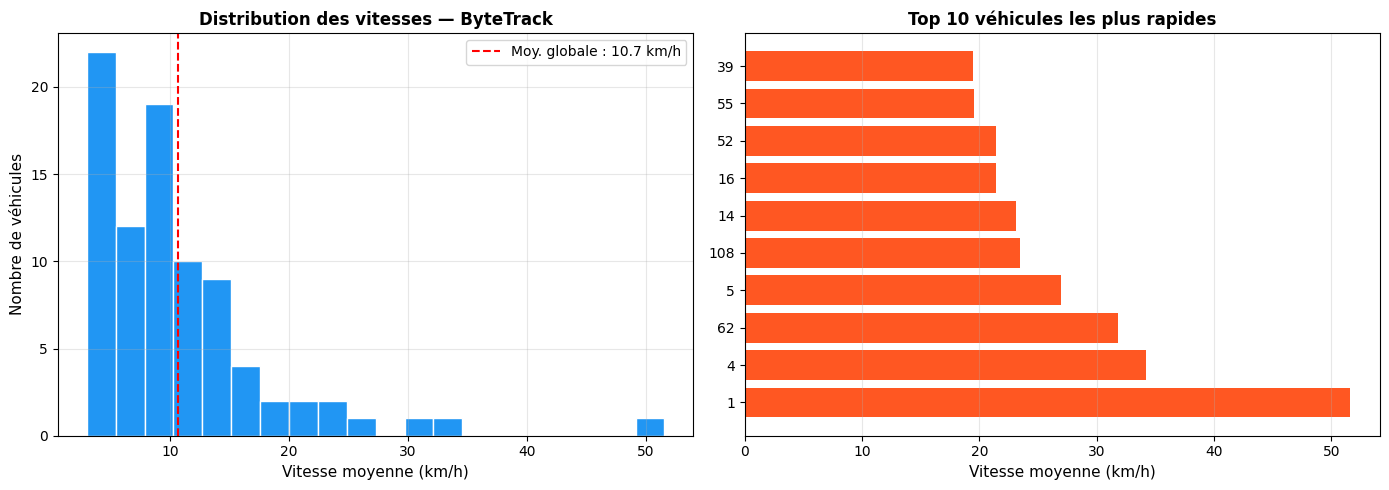

In [26]:
# ── Analyse de mouvement — Vitesse moyenne par véhicule ───────────────────────
FPS         = 25          # FPS de la séquence UA-DETRAC
PIX_PER_M   = 10          # calibration approximative (pixels → mètres)
TRACKER_USE = 'ByteTrack' # meilleur tracker selon tes résultats

pred_df = tracker_preds[TRACKER_USE].copy()

# Centre de chaque boîte
pred_df['cx'] = pred_df['x'] + pred_df['w'] / 2
pred_df['cy'] = pred_df['y'] + pred_df['h'] / 2
pred_df = pred_df.sort_values(['track_id', 'frame_id'])

# Distance pixel entre frames consécutives du même track
pred_df['dx']    = pred_df.groupby('track_id')['cx'].diff()
pred_df['dy']    = pred_df.groupby('track_id')['cy'].diff()
pred_df['df']    = pred_df.groupby('track_id')['frame_id'].diff()   # écart en frames
pred_df['dist']  = np.sqrt(pred_df['dx']**2 + pred_df['dy']**2)
pred_df['speed_px_f'] = pred_df['dist'] / pred_df['df'].replace(0, np.nan)  # px/frame
pred_df['speed_ms']   = pred_df['speed_px_f'] * FPS / PIX_PER_M            # m/s
pred_df['speed_kmh']  = pred_df['speed_ms'] * 3.6                           # km/h

# Résumé par véhicule
speed_summary = (
    pred_df.groupby('track_id')['speed_kmh']
    .agg(mean_speed='mean', max_speed='max', std_speed='std')
    .round(2)
    .reset_index()
)
print(speed_summary.sort_values('mean_speed', ascending=False).head(10))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(speed_summary['mean_speed'].dropna(), bins=20, color='#2196F3', edgecolor='white')
axes[0].set_xlabel('Vitesse moyenne (km/h)', fontsize=11)
axes[0].set_ylabel('Nombre de véhicules', fontsize=11)
axes[0].set_title(f'Distribution des vitesses — {TRACKER_USE}', fontsize=12, fontweight='bold')
axes[0].axvline(speed_summary['mean_speed'].mean(), color='red', linestyle='--',
                label=f"Moy. globale : {speed_summary['mean_speed'].mean():.1f} km/h")
axes[0].legend()
axes[0].grid(alpha=0.3)

top10 = speed_summary.nlargest(10, 'mean_speed')
axes[1].barh(top10['track_id'].astype(str), top10['mean_speed'], color='#FF5722')
axes[1].set_xlabel('Vitesse moyenne (km/h)', fontsize=11)
axes[1].set_title('Top 10 véhicules les plus rapides', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/motion_speed.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
def classify_vehicle_behavior(row):
    if row['mean_speed'] < 5:
        return '🔴 Stationnaire'
    elif row['mean_speed'] < 15:
        return '🟠 Lent (embouteillage)'
    elif row['mean_speed'] < 40:
        return '🟡 Normal (urbain)'
    elif row['mean_speed'] < 70:
        return '🟢 Rapide (route)'
    else:
        return '⚡ Très rapide / Anomalie'

speed_summary['behavior'] = speed_summary.apply(classify_vehicle_behavior, axis=1)

# Ajouter un flag anomalie si std > 20 (conduite erratique)
speed_summary['erratic'] = speed_summary['std_speed'] > 20

print(speed_summary[['track_id','mean_speed','max_speed','std_speed','behavior','erratic']]
      .sort_values('mean_speed', ascending=False).to_string(index=False))

 track_id  mean_speed  max_speed  std_speed                 behavior  erratic
        1       51.56      74.61      11.37         🟢 Rapide (route)    False
        4       34.17      67.73      13.61        🟡 Normal (urbain)    False
       62       31.82      62.34      13.54        🟡 Normal (urbain)    False
        5       26.97      77.54      16.33        🟡 Normal (urbain)    False
      108       23.47      80.31      23.65        🟡 Normal (urbain)     True
       14       23.11      70.39      17.64        🟡 Normal (urbain)    False
       16       21.46      76.20      15.82        🟡 Normal (urbain)    False
       52       21.43      93.68      16.15        🟡 Normal (urbain)    False
       55       19.56      56.26      14.00        🟡 Normal (urbain)    False
       39       19.43      58.18      10.94        🟡 Normal (urbain)    False
       46       17.52      39.13       7.42        🟡 Normal (urbain)    False
       10       17.04      44.60       9.62        🟡 Normal (urb

## 15. Figures IEEE

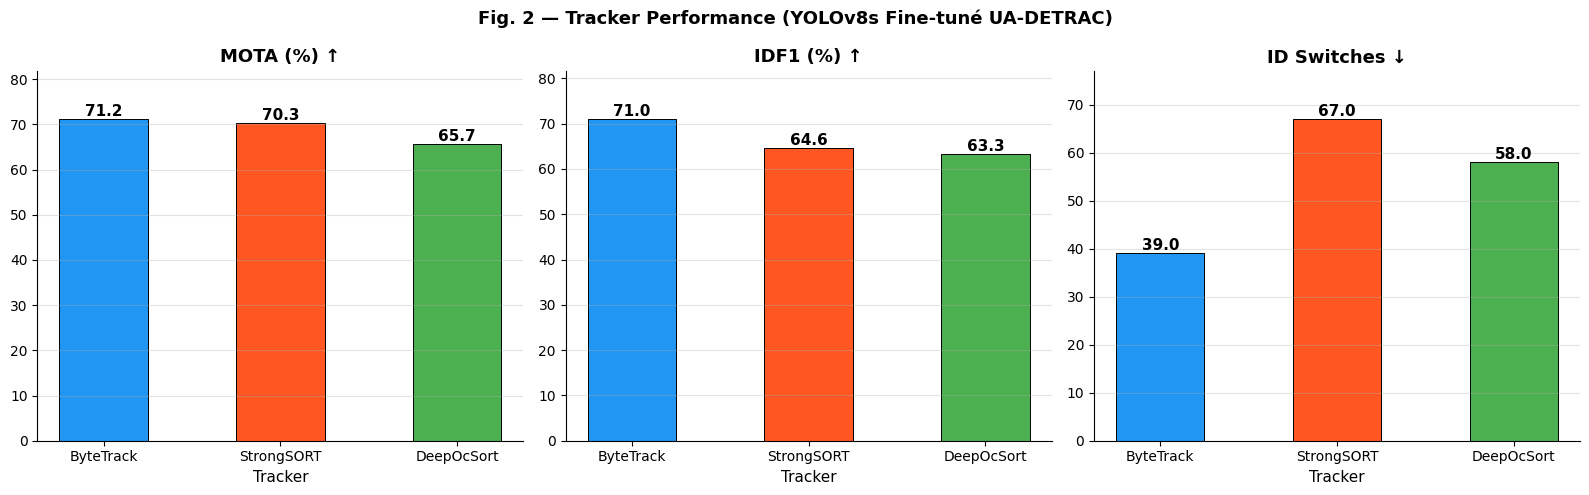

In [30]:
COLORS = ['#2196F3', '#FF5722', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plots = [('MOTA↑ (%)', 'MOTA (%) ↑'), ('IDF1↑ (%)', 'IDF1 (%) ↑'), ('ID Sw.↓', 'ID Switches ↓')]
for ax, (col, label) in zip(axes, plots):
    bars = ax.bar(summary_df['Tracker'], summary_df[col],
                  color=COLORS, edgecolor='black', linewidth=0.7, width=0.5)
    for bar, val in zip(bars, summary_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(summary_df[col])*0.01,
                f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Tracker', fontsize=11)
    ax.set_ylim(0, max(summary_df[col])*1.15)
    ax.grid(axis='y', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Fig. 2 — Tracker Performance (YOLOv8s Fine-tuné UA-DETRAC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig2_tracker_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

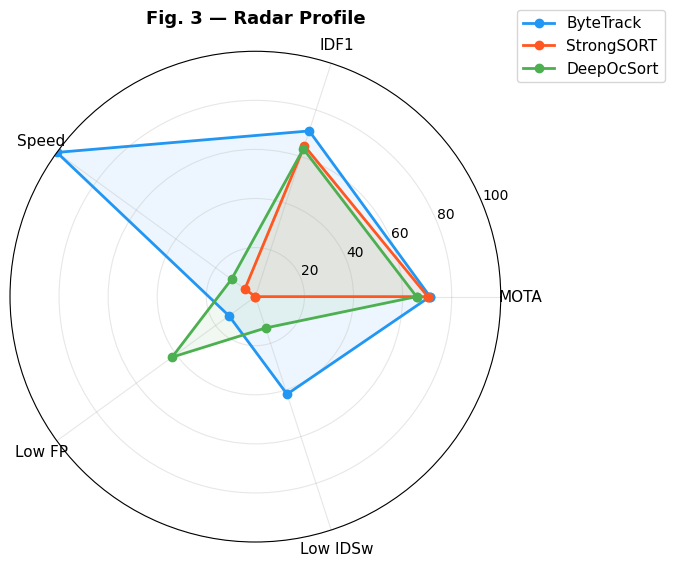

In [31]:
# Radar chart
rdf = summary_df.copy()
rdf['FPS_norm'] = (rdf['FPS↑'] / rdf['FPS↑'].max()) * 100
mx_fp = rdf['FP↓'].max(); mx_sw = rdf['ID Sw.↓'].max()
rdf['FP_inv']   = 100 - (rdf['FP↓']     / mx_fp * 100) if mx_fp > 0 else 100
rdf['IDSw_inv'] = 100 - (rdf['ID Sw.↓'] / mx_sw * 100) if mx_sw > 0 else 100

radar_m = ['MOTA↑ (%)', 'IDF1↑ (%)', 'FPS_norm', 'FP_inv', 'IDSw_inv']
radar_l = ['MOTA', 'IDF1', 'Speed', 'Low FP', 'Low IDSw']
N       = len(radar_m)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (_, row) in enumerate(rdf.iterrows()):
    vals = [row[m] for m in radar_m] + [row[radar_m[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=COLORS[i], label=row['Tracker'])
    ax.fill(angles, vals, alpha=0.08, color=COLORS[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_l, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Fig. 3 — Radar Profile', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig3_radar.png', dpi=150, bbox_inches='tight')
plt.show()

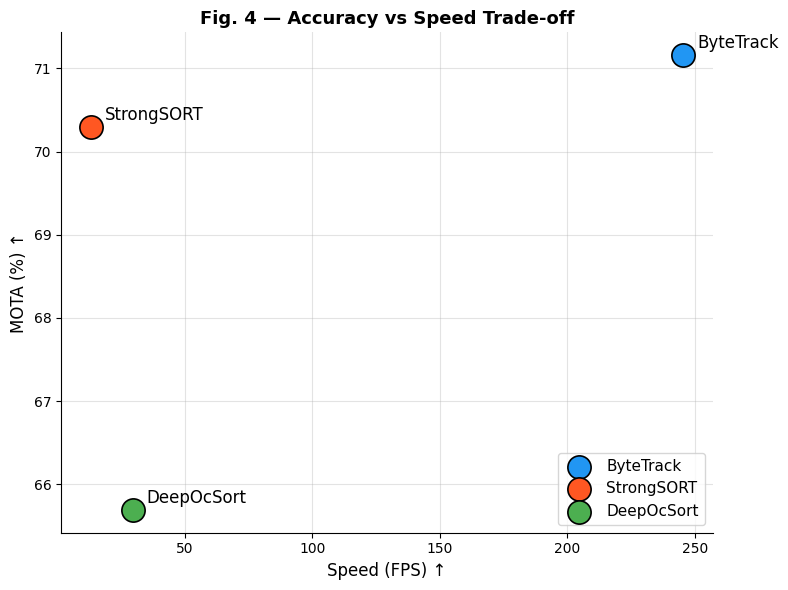

In [32]:
# Accuracy vs Speed
fig, ax = plt.subplots(figsize=(8, 6))
for i, (_, row) in enumerate(summary_df.iterrows()):
    ax.scatter(row['FPS↑'], row['MOTA↑ (%)'], s=280, color=COLORS[i],
               zorder=5, edgecolors='black', linewidth=1.2, label=row['Tracker'])
    ax.annotate(row['Tracker'], (row['FPS↑'], row['MOTA↑ (%)']),
                textcoords='offset points', xytext=(10,5), fontsize=12)
ax.set_xlabel('Speed (FPS) ↑', fontsize=12)
ax.set_ylabel('MOTA (%) ↑', fontsize=12)
ax.set_title('Fig. 4 — Accuracy vs Speed Trade-off', fontsize=13, fontweight='bold')
ax.grid(alpha=0.35)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig4_accuracy_speed.png', dpi=150, bbox_inches='tight')
plt.show()

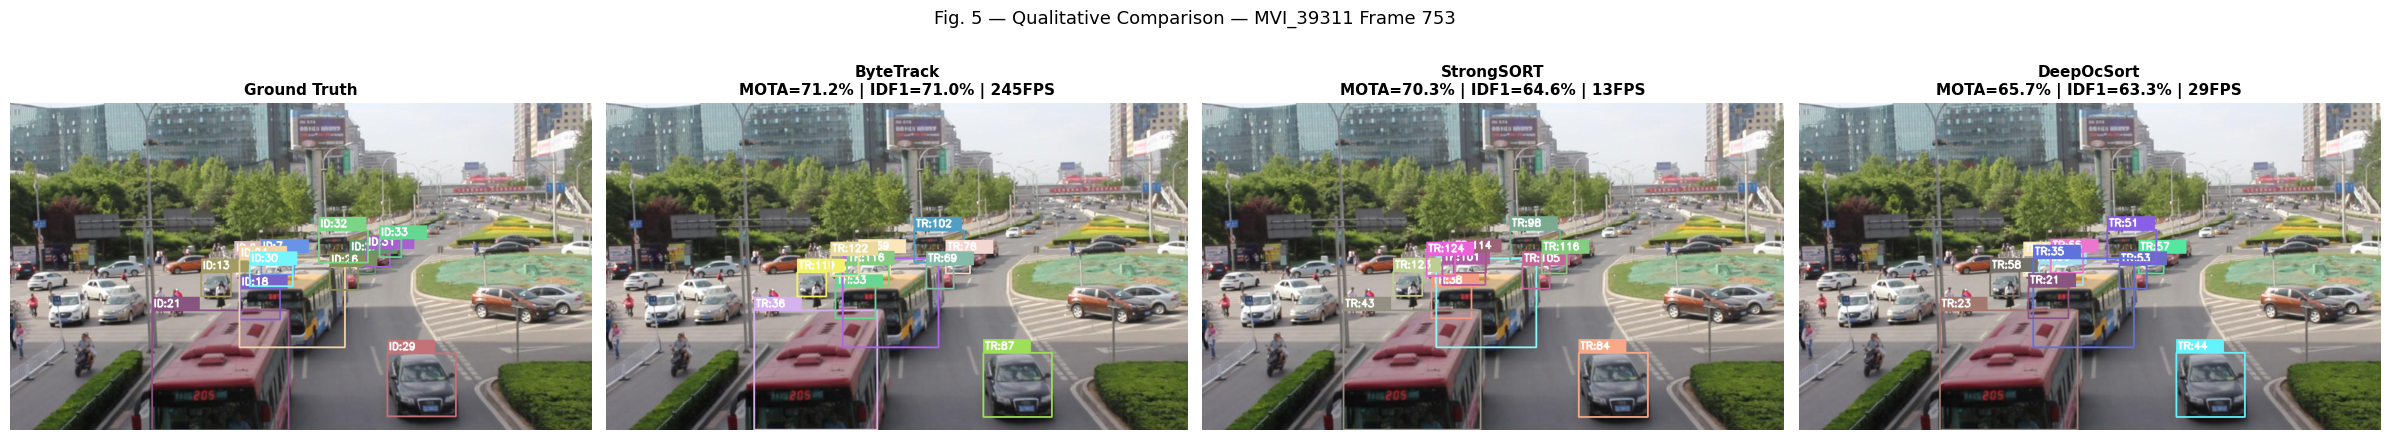

In [33]:
# Qualitative comparison
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes[0].imshow(draw_boxes_df(img_v, gt_fv))
axes[0].set_title('Ground Truth', fontsize=11, fontweight='bold')
axes[0].axis('off')
for ax, tname in zip(axes[1:], TRACKER_NAMES):
    pf   = tracker_preds[tname][tracker_preds[tname]['frame_id']==FRAME_VIS]
    mota = tracker_metrics[tname]['mota'].values[0]*100
    idf1 = tracker_metrics[tname]['idf1'].values[0]*100
    fps  = tracker_fps[tname]
    ax.imshow(draw_boxes_df(img_v, pf, label_prefix='TR'))
    ax.set_title(f'{tname}\nMOTA={mota:.1f}% | IDF1={idf1:.1f}% | {fps:.0f}FPS',
                 fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle(f'Fig. 5 — Qualitative Comparison — {SEQ_TEST} Frame {FRAME_VIS}', fontsize=13)
plt.tight_layout()
plt.savefig('/content/fig5_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()

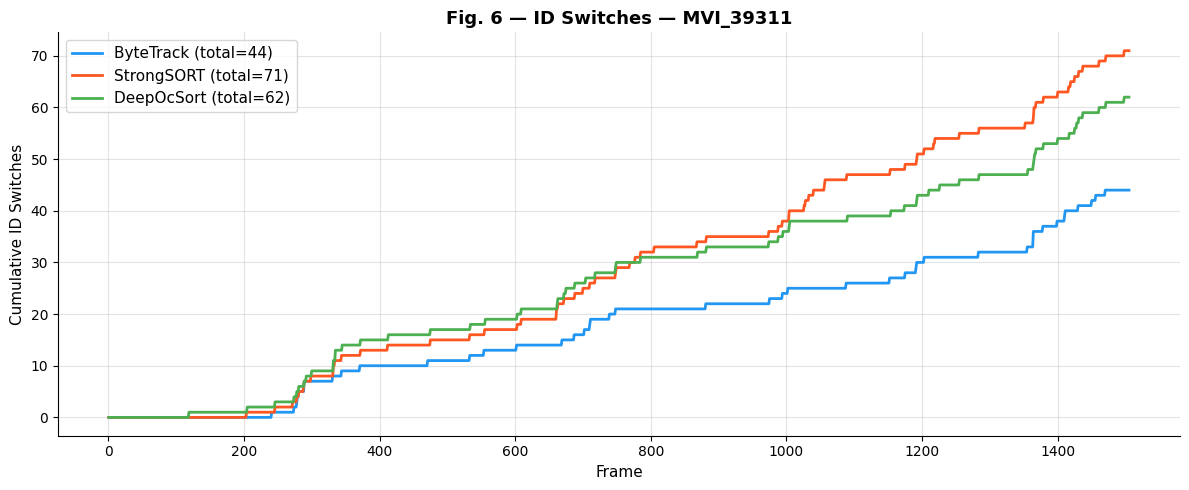

In [34]:
# ID Switches cumulatifs
frame_ids_sorted = sorted(gt_eval['frame_id'].unique())
fig, ax = plt.subplots(figsize=(12, 5))
color_map = {'ByteTrack':'#2196F3','StrongSORT':'#FF5722','DeepOcSort':'#4CAF50'}
for tname in TRACKER_NAMES:
    pred_df = tracker_preds[tname]
    cum, tot, prev = [], 0, {}
    for fid in frame_ids_sorted:
        gt_f   = gt_eval[gt_eval['frame_id']==fid]
        pred_f = pred_df[pred_df['frame_id']==fid]
        sw = 0
        for _, gr in gt_f.iterrows():
            best_iou, best_pid = IOU_MATCH_THRESHOLD, None
            for _, pr in pred_f.iterrows():
                iou = compute_iou([gr['x'],gr['y'],gr['w'],gr['h']],
                                  [pr['x'],pr['y'],pr['w'],pr['h']])
                if iou > best_iou: best_iou, best_pid = iou, int(pr['track_id'])
            gtid = int(gr['track_id'])
            if best_pid is not None:
                if gtid in prev and prev[gtid] != best_pid: sw += 1
                prev[gtid] = best_pid
        tot += sw; cum.append(tot)
    ax.plot(frame_ids_sorted, cum, '-', lw=2,
            color=color_map[tname], label=f'{tname} (total={tot})')
ax.set_xlabel('Frame', fontsize=11)
ax.set_ylabel('Cumulative ID Switches', fontsize=11)
ax.set_title(f'Fig. 6 — ID Switches — {SEQ_TEST}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig6_id_switches.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Résumé final + Téléchargement

In [35]:
best_tracker = summary_df.loc[summary_df['Score'].idxmax(), 'Tracker']
best_row     = summary_df.loc[summary_df['Score'].idxmax()]

print('='*65)
print('  RÉSUMÉ FINAL — Smart Traffic Analysis & Safety Monitoring')
print('='*65)
print(f'  Détecteur  : YOLOv8s Fine-tuné UA-DETRAC')
print(f'  Filtrage   : MOG2 (ratio={MOG2_MOTION_RATIO}, area={MIN_BOX_AREA}px²)')
print(f'  Dataset    : UA-DETRAC — {SEQ_TEST}')
print(f'  Frames     : {gt_eval.frame_id.nunique()}')
print(f'  Véhicules  : {gt_eval.track_id.nunique()} (GT)')
print()
print(summary_df[['Tracker','MOTA↑ (%)','IDF1↑ (%)','ID Sw.↓','FP↓','FN↓','FPS↑']].to_string(index=False))
print()
print(f'  🥇 Meilleur MOTA    : {summary_df.loc[summary_df["MOTA↑ (%)"].idxmax(), "Tracker"]}')
print(f'  🥇 Meilleur IDF1    : {summary_df.loc[summary_df["IDF1↑ (%)"].idxmax(), "Tracker"]}')
print(f'  🥇 Moins ID Switches: {summary_df.loc[summary_df["ID Sw.↓"].idxmin(), "Tracker"]}')
print(f'  🥇 Plus rapide      : {summary_df.loc[summary_df["FPS↑"].idxmax(), "Tracker"]}')
print(f'  🏆 Meilleur global  : {best_tracker} (score={best_row["Score"]:.2f})')

tracker_preds[best_tracker].to_csv('/content/best_tracker_predictions.csv', index=False)
summary_df.to_csv('/content/tracking_summary_table.csv', index=False)

metrics_export = {
    'best_tracker'    : best_tracker,
    'sequence'        : SEQ_TEST,
    'detector'        : 'YOLOv8s-FT-UA-DETRAC',
    'conf_threshold'  : CONF_THRESHOLD,
    'mog2_ratio'      : MOG2_MOTION_RATIO,
    'min_box_area'    : MIN_BOX_AREA,
    'results'         : summary_df.drop(columns='Score').to_dict(orient='records')
}
with open('/content/tracking_results.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)

# Copier aussi le meilleur modèle dans Drive
shutil.copy(f'{FT_OUTPUT_DIR}/detrac/weights/best.pt',
            f'{DRIVE_WEIGHTS_DIR}/final_best.pt')
print('\n📁 Fichiers sauvegardés + poids copiés sur Drive')

  RÉSUMÉ FINAL — Smart Traffic Analysis & Safety Monitoring
  Détecteur  : YOLOv8s Fine-tuné UA-DETRAC
  Filtrage   : MOG2 (ratio=0.02, area=250px²)
  Dataset    : UA-DETRAC — MVI_39311
  Frames     : 1505
  Véhicules  : 51 (GT)

   Tracker  MOTA↑ (%)  IDF1↑ (%)  ID Sw.↓  FP↓  FN↓  FPS↑
 ByteTrack      71.16      71.01       39  124 6313 245.4
StrongSORT      70.30      64.64       67  143 6460  13.0
DeepOcSort      65.69      63.31       58   83 7565  29.5

  🥇 Meilleur MOTA    : ByteTrack
  🥇 Meilleur IDF1    : ByteTrack
  🥇 Moins ID Switches: ByteTrack
  🥇 Plus rapide      : ByteTrack
  🏆 Meilleur global  : ByteTrack (score=76.87)

📁 Fichiers sauvegardés + poids copiés sur Drive


In [36]:
from google.colab import files

output_files = [
    '/content/best_tracker_predictions.csv',
    '/content/tracking_results.json',
    '/content/tracking_summary_table.csv',
    '/content/fig1_gt_vs_yolo.png',
    '/content/fig2_tracker_comparison.png',
    '/content/fig3_radar.png',
    '/content/fig4_accuracy_speed.png',
    '/content/fig5_qualitative.png',
    '/content/fig6_id_switches.png',
]

zip_path = '/content/tracking_final.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in output_files:
        if os.path.exists(fpath):
            zf.write(fpath, os.path.basename(fpath))
            print(f'  ✅ {os.path.basename(fpath)}')
        else:
            print(f'  ❌ {fpath} non trouvé')

print('\nTéléchargement...')
files.download(zip_path)

  ✅ best_tracker_predictions.csv
  ✅ tracking_results.json
  ✅ tracking_summary_table.csv
  ✅ fig1_gt_vs_yolo.png
  ✅ fig2_tracker_comparison.png
  ✅ fig3_radar.png
  ✅ fig4_accuracy_speed.png
  ✅ fig5_qualitative.png
  ✅ fig6_id_switches.png

Téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>